In [2]:
%load_ext autoreload
%autoreload 2
from corti.bezier_multirotor_planning import derive_bezier7, derive_bezier3
from corti.TimeOptBez import find_opt_multirotor_time

import numpy as np

from cyecca.models.bezier import derive_ref, derive_eulerB321_to_quat, derive_multirotor
from cyecca.lie import SO3EulerB321, SO3Quat
import casadi as ca
from cyecca.models.rdd2 import (
    derive_position_control,
    derive_attitude_control,
    derive_attitude_rate_control,
)
from cyecca.models.rdd2_loglinear import (
    derive_se23_error,
    derive_outerloop_control,
    derive_so3_attitude_control,
)
from cyecca.models.rdd2 import derive_control_allocation
from cyecca.models.quadrotor import derive_model, sim

from sim.multirotor_plan import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
f = derive_control_allocation()["f_alloc"]
f_euler_to_quat = derive_eulerB321_to_quat()["eulerB321_to_quat"]
f_att_rate_control = derive_attitude_rate_control()["attitude_rate_control"]
f_multirotor = derive_multirotor()["bezier_multirotor"]
f_se23_error = derive_se23_error()["se23_error"]
f_se23_control = derive_outerloop_control()["se23_position_control"]
f_so3_control = derive_so3_attitude_control()["so3_attitude_control"]
f_ref = derive_ref()["f_ref"]
model = derive_model()

KeyError: 'se23_position_control'

In [4]:
bezier7 = derive_bezier7()
bezier3 = derive_bezier3()
dt = 1e-2

# bezier boundary conditions
bc_t = np.array(
    [
        [  # position
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 2],  # wp0, x, y, z
            [-2, 1, 2],
            [-4, 0, 2],
            [-2, -1, 2],
            [0, 0, 2],
            [2, 1, 2],
            [4, 0, 2],
            [2, -1, 2],
            [0, 0, 2],
            [0, 0, 0],
        ],
        [  # velocity
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 0.1],
            [-5, 2.5, 0],
            [-5, -2.5, 0],
            [5, -2.5, 0],
            [5, 2.5, 0],
            [5, 2.5, 0],
            [5, -2.5, 0],
            [-5, -2.5, 0],
            [-5, 2.5, 0],
            [0, 0, -0.1],
        ],
        [  # accel
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],  # wp0, x, y, z
        ],
        [  # jerk
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ]
)
bc_psi_list = np.array(
    [
        [  # attitude
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [  # angular velocity
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ]
)

# solve for bezier trajectories
k = 10
T0_list = []
PX_list = []
PY_list = []
PZ_list = []
Ppsi_list = []
for i in range(bc_t.shape[1] - 1):
    bc = bc_t[:, i : i + 2, :]
    bc_psi = bc_psi_list[:, i : i + 2, :]
    T0 = 0.1 # find_opt_multirotor_time(8, 4, bc, bc_psi, k, 1)[0]
    PX = np.array(bezier7["bezier7_solve"](bc[:, 0, 0], bc[:, 1, 0], T0)).reshape(-1)
    PY = np.array(bezier7["bezier7_solve"](bc[:, 0, 1], bc[:, 1, 1], T0)).reshape(-1)
    PZ = np.array(bezier7["bezier7_solve"](bc[:, 0, 2], bc[:, 1, 2], T0)).reshape(-1)
    Ppsi = np.array(
        bezier3["bezier3_solve"](bc_psi[:, 0, 2], bc_psi[:, 1, 2], T0)
    ).reshape(-1)
    T0_list.append(T0)
    PX_list.append(PX)
    PY_list.append(PY)
    PZ_list.append(PZ)
    Ppsi_list.append(Ppsi)

# generate trajectory
x_list = []
y_list = []
z_list = []
vx_list = []
vy_list = []
vz_list = []
ax_list = []
ay_list = []
az_list = []
jx_list = []
jy_list = []
jz_list = []
sx_list = []
sy_list = []
sz_list = []
psi_list = []
dpsi_list = []
ddpsi_list = []
t_list = []
omega1_list = []
omega2_list = []
omega3_list = []
for leg in range(len(T0_list)):
    t_leg = np.array([np.arange(0, T0_list[leg], dt)])
    traj_x = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PX_list[leg])).T
    traj_y = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PY_list[leg])).T
    traj_z = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PZ_list[leg])).T
    traj_psi = np.array(bezier3["bezier3_traj"](t_leg, T0_list[leg], Ppsi_list[leg])).T
    x = traj_x[:, 0]
    y = traj_y[:, 0]
    z = traj_z[:, 0]
    vx = traj_x[:, 1]
    vy = traj_y[:, 1]
    vz = traj_z[:, 1]
    ax = traj_x[:, 2]
    ay = traj_y[:, 2]
    az = traj_z[:, 2]
    jx = traj_x[:, 3]
    jy = traj_y[:, 3]
    jz = traj_z[:, 3]
    sx = traj_x[:, 4]
    sy = traj_y[:, 4]
    sz = traj_z[:, 4]
    psi = traj_psi[:, 0]
    dpsi = traj_psi[:, 1]
    ddpsi = traj_psi[:, 2]
    for j in range(x.shape[0]):
        [omega, q_sp, omega_ff, _, M_ff, thrust_ff] = f_ref(
            psi[j], dpsi[j], ddpsi[j], np.array([vx[j], vy[j], vz[j]]).reshape(3,), 
            np.array([ax[j], ay[j], az[j]]).reshape(3,), np.array([jx[j], jy[j], jz[j]]).reshape(3,), np.array([sx[j], sy[j], sz[j]]).reshape(3,)
        )
        omega = np.array(omega).reshape(3,)
        omega1_list.append(omega[0])
        omega2_list.append(omega[1])
        omega3_list.append(omega[2])
    t = t_leg + leg * T0
    t_list.extend(t.reshape(-1))
    x_list.extend(x)
    y_list.extend(y)
    z_list.extend(z)
    vx_list.extend(vx)
    vy_list.extend(vy)
    vz_list.extend(vz)
    ax_list.extend(ax)
    ay_list.extend(ay)
    az_list.extend(az)
    jx_list.extend(jx)
    jy_list.extend(jy)
    jz_list.extend(jz)
    sx_list.extend(sx)
    sy_list.extend(sy)
    sz_list.extend(sz)
    psi_list.extend(psi)
    dpsi_list.extend(dpsi)
    ddpsi_list.extend(ddpsi)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


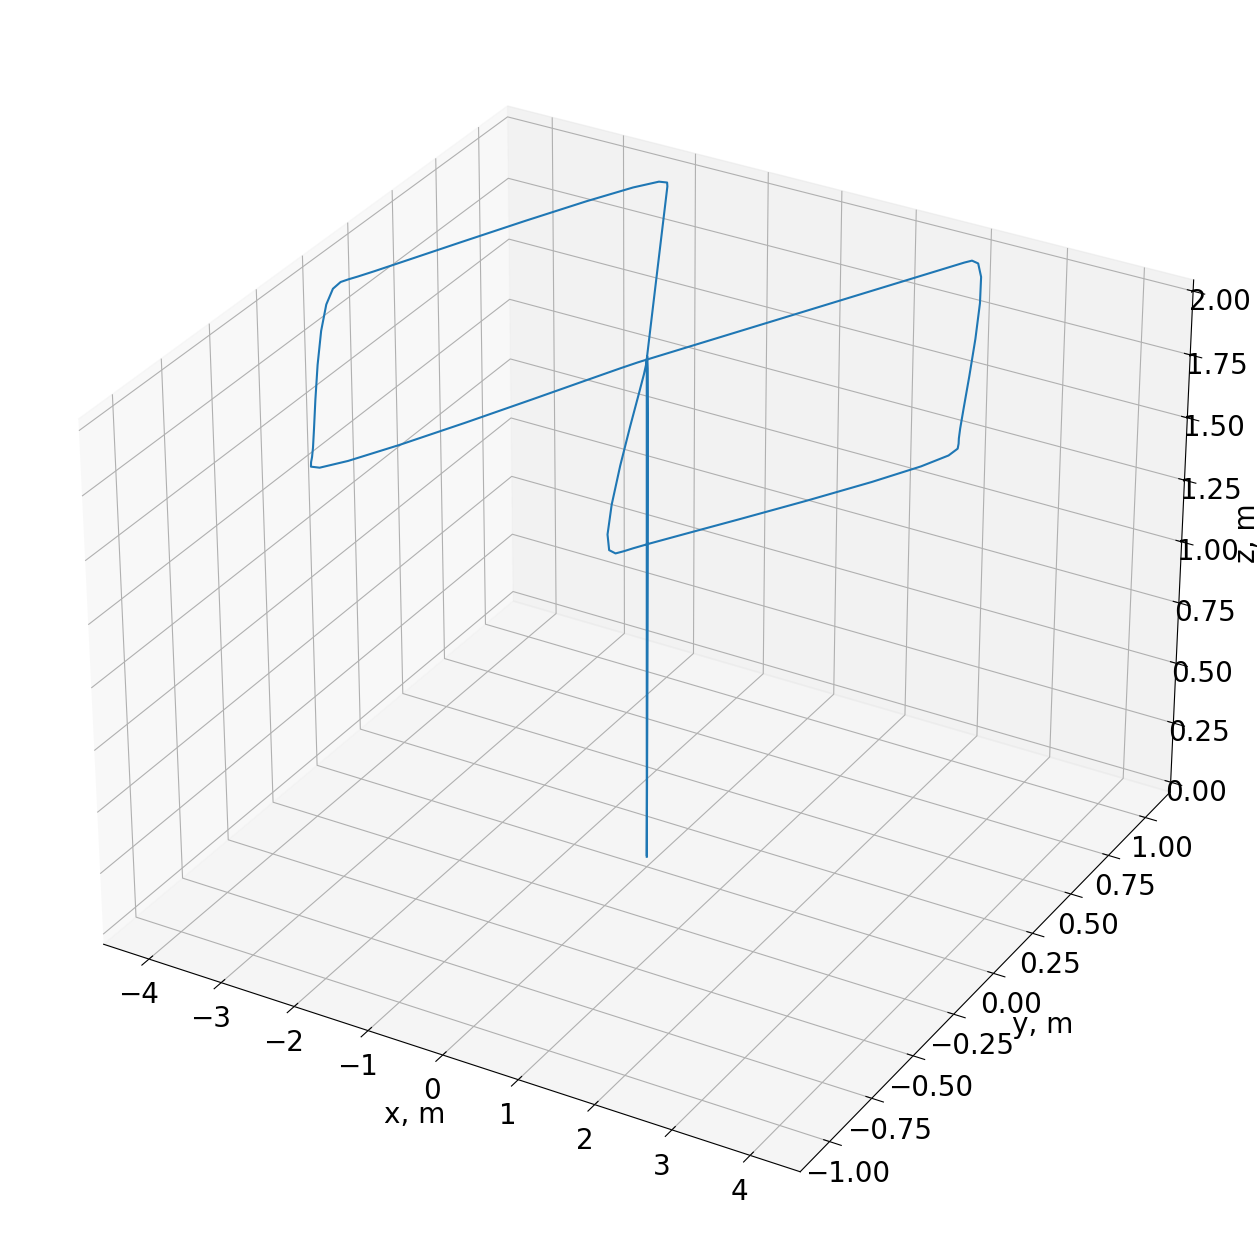

In [5]:


fig = plt.figure(figsize=(13,13))
plt.rcParams.update({'font.size': 20})
ax = fig.add_subplot(111, projection="3d")
ax.plot(x_list, y_list, z_list)
ax.set_xlabel('x, m', labelpad=10)
ax.set_ylabel('y, m', labelpad=12)
ax.set_zlabel('z, m', rotation=90, labelpad=8)
# ax.set_title('Reference Trajectory')
plt.axis('auto')
plt.tight_layout()
plt.savefig('figures/ref_traj.eps', format='eps', bbox_inches='tight')

In [79]:
# loglinear
model = derive_model()
x0_dict = model["x0_defaults"]
x0 = None
p = None
if x0 is not None:
    for k in x0.keys():
        if not k in x0_dict.keys():
            raise KeyError(k)
        x0_dict[k] = x0[k]
p_dict = model["p_defaults"]
if p is not None:
    for k in p.keys():
        if not k in p_dict.keys():
            raise KeyError(k)
        p_dict[k] = p[k]
x = np.array(list(x0_dict.values()), dtype=float)
p = np.array(list(p_dict.values()), dtype=float)
u = np.zeros(4, dtype=float)
t1 = 0
k_p_att = np.array([5, 5, 2], dtype=float)
leg = 0
CT = 8.54858e-06

thrust_trim = 2 * 9.8
# attitude rate
kp = np.array([0.3, 0.3, 0.05], dtype=float)
ki = np.array([0, 0, 0], dtype=float)
kd = np.array([0.0, 0.0, 0], dtype=float)
i0 = 0
e0 = np.zeros(3, dtype=float)  # error for attitude rate loop
de0 = np.zeros(3, dtype=float)  # deriv of att error (for lowpass)
f_cut = 10.0
i_max = np.array([0, 0, 0], dtype=float)
dae = model["dae"]
z_i = 0
pos_list = []
u_alloc_list = []
M_ff_list = []
thrust_ff_list = []
x_sp_list = []
y_sp_list = []
z_sp_list = []
v_sp_list = []
a_sp_list = []
j_sp_list = []
s_sp_list = []
motor_omega_list = []
t1_list = []
zeta_list = []
for i in range(len(t_list)):
    t = t_list[i]
    if t > T0 * (leg + 1):
        leg += 1
    t_bezier = t - T0 * leg - dt / 2
    pw = np.array(
        [
            x[model["x_index"]["position_op_w_0"]],
            x[model["x_index"]["position_op_w_1"]],
            x[model["x_index"]["position_op_w_2"]],
        ]
    )
    vw = np.array(
        [
            x[model["x_index"]["velocity_w_p_b_0"]],
            x[model["x_index"]["velocity_w_p_b_1"]],
            x[model["x_index"]["velocity_w_p_b_2"]],
        ]
    )
    q = np.array(
        [
            x[model["x_index"]["quaternion_wb_0"]],
            x[model["x_index"]["quaternion_wb_1"]],
            x[model["x_index"]["quaternion_wb_2"]],
            x[model["x_index"]["quaternion_wb_3"]],
        ]
    )
    omega = np.array(
        [
            x[model["x_index"]["omega_wb_b_0"]],
            x[model["x_index"]["omega_wb_b_1"]],
            x[model["x_index"]["omega_wb_b_2"]],
        ]
    )
    [
        x_sp,
        y_sp,
        z_sp,
        psi_sp,
        dpsi_sp,
        ddpsi_sp,
        vw_sp,
        aw_sp,
        jw_sp,
        sw_sp,
    ] = f_multirotor(
        t_bezier, T0, PX_list[leg], PY_list[leg], PZ_list[leg], Ppsi_list[leg]
    )
    [_, q_sp, omega_ff, _, M_ff, thrust_ff] = f_ref(
        psi_sp, dpsi_sp, ddpsi_sp, vw_sp, aw_sp, jw_sp, sw_sp
    )
    qc_sp = f_euler_to_quat(psi_sp, 0, 0)
    pw_sp = np.array([x_sp, y_sp, z_sp]).reshape(-1)
    zeta = f_se23_error(
        pw,
        vw,
        q,
        pw_sp,
        vw_sp,
        q_sp,
    )
    # position control: world frame
    [thrust, q_sp, z_i] = f_se23_control(
        thrust_trim,
        k_p_att,
        zeta,
        aw_sp,
        q,
        z_i,
        dt,
    )
    omega_fb = f_so3_control(k_p_att, q, q_sp)
    omega_sp = omega_fb + omega_ff
    M_fb, i1, e1, de1, alpha = f_att_rate_control(
        kp,
        ki,
        kd,
        f_cut,
        i_max,
        omega,
        omega_sp,
        i0,
        e0,
        de0,
        dt,
    )
    i0 = i1
    e0 = e1
    de0 = de1
    M_sp = M_fb + M_ff
    u, Fp, Fm, Ft, Msat = f(100, 0.25 / ca.sqrt(2), 0.016, CT, thrust, M_sp)
    try:
        f_int = ca.integrator("test", "cvodes", dae, t, t + dt)
        res = f_int(x0=x, z0=0, p=p, u=u)
    except RuntimeError as e:
        print(e)
        xdot = model["f"](x=x, u=u, p=p)
        print(xdot, x, u, p)
        raise e
    t1 += dt
    x = np.array(res["xf"]).reshape(-1)
    res["p"] = p_dict
    pos = x[0:3]
    pos_list.append(np.array(pos).reshape(-1))
    u_alloc_list.append(np.array(u).reshape(-1))
    M_ff_list.append(np.array(M_ff).reshape(-1))
    thrust_ff_list.append(np.array(thrust_ff).reshape(-1))
    zeta_list.append(np.array(zeta).reshape(-1))
# res["yf"] = model["g"](res["xf"], u, p_dict.values())

for k in ["xf", "zf"]:
    res[k] = np.array(res[k])

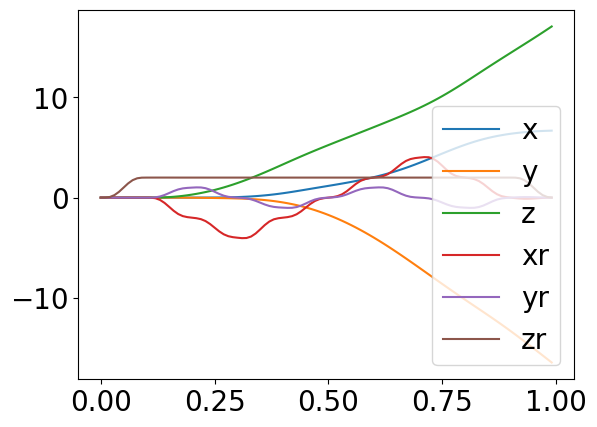

In [80]:
import matplotlib.pyplot as plt

t = np.arange(0, t_list[-1] + dt, dt)
plt.plot(t, np.array(pos_list)[:, 0])
plt.plot(t, np.array(pos_list)[:, 1])
plt.plot(t, np.array(pos_list)[:, 2])

plt.plot(t, x_list)
plt.plot(t, y_list)
plt.plot(t, z_list)
plt.legend(["x", "y", "z", "xr", "yr", "zr"])

31.178325032539757
67.62533569556201
68.20184463017674


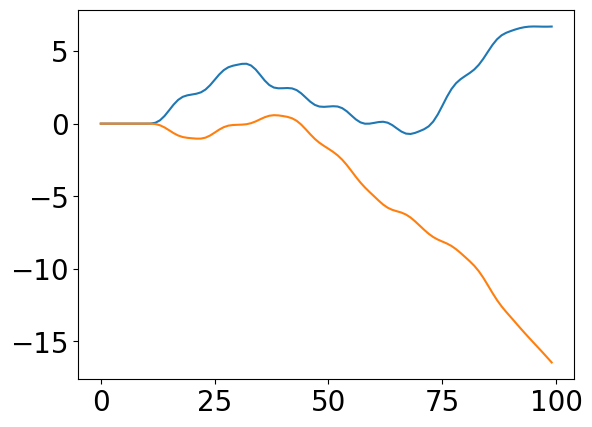

In [81]:
plt.plot(np.array(pos_list)[:, 0] - x_list)
plt.plot(np.array(pos_list)[:, 1] - y_list)
# plt.plot(np.array(pos_list)[:, 2]-z_list)
print(np.linalg.norm(np.array(pos_list)[:, 0] - x_list))
print(np.linalg.norm(np.array(pos_list)[:, 1] - y_list))
print(np.linalg.norm(np.array(pos_list)[:, 2] - z_list))

In [1]:
%load_ext autoreload
%autoreload 2
from lie.SE23 import *
from flowpipe.inner_bound import *
from flowpipe.outer_bound import *
from flowpipe.flowpipe import *
from sim.multirotor_control import *
from sim.multirotor_plan import *


In [6]:
k = 10
ref = generate_path(bc_t, k, 0.01)

In [7]:
ax = [np.min(ref['acc_x']), np.max(ref['acc_x'])]
ay = [np.min(ref['acc_y']), np.max(ref['acc_y'])]
az = [np.min(ref['acc_z']), np.max(ref['acc_z'])]
omega1 = [np.min(ref['omega_1']), np.max(ref['omega_1'])]
omega2 = [np.min(ref['omega_2']), np.max(ref['omega_2'])]
omega3 = [np.min(ref['omega_3']), np.max(ref['omega_3'])]

In [7]:
# ax = [np.min(ax_list), np.max(ax_list)]
# ay = [np.min(ay_list), np.max(ay_list)]
# az = [np.min(az_list)+9.8, np.max(az_list)+9.8]
# omega1 = [np.min(omega1_list), np.max(omega1_list)]
# omega2 = [np.min(omega2_list), np.max(omega2_list)]
# omega3 = [np.min(omega3_list), np.max(omega3_list)]

In [8]:
# Set disturbance here
w1 =  1 #1 #.2 # disturbance for translational (impact a)
w2 = 0.01 # disturbance for angular (impact alpha)

In [9]:
# solve LMI
sol = find_omega_invariant_set(omega1, omega2, omega3) 

# Initial condition
P = sol['P']
e0 = np.array([0,0,0]) # initial error
beta = (e0.T@P@e0) # initial Lyapnov value

# find bound
omegabound = omega_bound(omega1, omega2, omega3, w2, beta) # result for inner bound
print(omegabound)

0.003162277666795747


In [10]:
import cvxpy as cp

def solve_lmi(alpha, A_list, verbosity=False):
    n = 9 # Augmented state dim
    P = cp.Variable((n,n), 'P', PSD=True)
    P1 = P[:3, :]
    P2 = P[3:6, :]
    P3 = P[6:, :]
    mu1 = cp.Variable((1,1), 'mu_1')
    mu2 = cp.Variable((1,1), 'mu_2')
    mu3 = cp.Variable((1,1), 'mu_3')
    gamma = mu1 + mu2 + mu3
    # gamma = cp.Variable((1,1), 'gamma')
    constraints = [P>>np.eye(9)]

    for Ai in A_list:
        constraints += [cp.bmat([[Ai.T*P + P*Ai + alpha*P, P],
                                [P1, -alpha*mu1*np.eye(3), np.zeros((3,3)), np.zeros((3,3))],
                                [P2, np.zeros((3,3)), -alpha*mu2*np.eye(3), np.zeros((3,3))],
                                [P3, np.zeros((3,3)), np.zeros((3,3)), -alpha*mu3*np.eye(3)]]) << 0] 
    prob = cp.Problem(cp.Minimize(gamma), constraints) 
    try:
        prob.solve()
        cost = gamma.value
        return {
            'cost': cost,
            'prob': prob,
            'mu1': mu1.value,
            'mu2': mu2.value,
            'mu3': mu3.value,
            'P': np.array(P.value),
            'alpha':alpha
            }

    except Exception as e:
        print(e)
        cost = -1    
        return {
            'cost': cost,
        }   

In [16]:
import cyecca.lie as lie
import casadi as ca
A = -np.array(ca.DM(lie.se23.elem(ca.DM([0, 0, 0, 0, 0, 9.8, 0, 0, 0])).ad()))
print(A)
#A = -ca.DM(se23.elem(ca.vertcat(0, 0, 0, 0, 0, 9.8, 0, 0, 0)).ad() + adC_matrix())
B = np.eye(9)
Q = 8*np.eye(9)
R = np.eye(9)
K, _, _ = control.lqr(A, B, Q, R)

A_list = []
for x0 in [0]:
    for x1 in [0]:
        for x2 in [0]:
            for x3 in ax:
                for x4 in ay:
                    for x5 in az:
                        for x6 in omega1:
                            for x7 in omega2:
                                for x8 in omega3:
                                    Ai = -np.array(ca.DM(lie.se23.elem(ca.DM([x0, x1, x2, x3, x4, x5, x6, x7, x8])).ad()+SE23Dcm.adC_matrix())) - B@K
                                    A_list.append(Ai)

[[-0.  -0.  -0.  -0.  -0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0.  -0.  -0.   9.8 -0. ]
 [-0.  -0.  -0.  -0.  -0.  -0.  -9.8 -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0.  -0.  -0.  -0.  -0. ]
 [-0.  -0.  -0.  -0.  -0.  -0.  -0.  -0.  -0. ]]


In [17]:
%%time
sol_LMI = solve_lmi(0.3, A_list)

CPU times: user 2min 53s, sys: 3.03 ms, total: 2min 53s
Wall time: 2min 53s


In [12]:
eig=[]
for A in A_list:
    eig.append(np.linalg.eig(A)[0])
print(-np.real(np.max(eig)))

1.1715623632436563


In [13]:
%%time
verbosity = 0
alpha_opt = scipy.optimize.fminbound(lambda alpha: solve_lmi(alpha, A_list, verbosity=verbosity)['cost'], x1=0.001, x2=-np.real(np.max(eig)), disp=True if verbosity > 0 else False)

CPU times: user 13min 49s, sys: 48.3 ms, total: 13min 49s
Wall time: 13min 50s


In [17]:
alpha_opt

1.1352494

In [13]:
%%time
sol_LMI = solve_lmi(1.1352494, A_list)
sol_LMI

CPU times: user 15.6 s, sys: 7.7 ms, total: 15.7 s
Wall time: 15.7 s


{'cost': array([[1.93366183]]),
 'prob': Problem(Minimize(Expression(AFFINE, UNKNOWN, (1, 1))), [PSD(Expression(AFFINE, UNKNOWN, (9, 9))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UNKNOWN, (18, 18))), PSD(Expression(AFFINE, UN

In [14]:
prob = sol['prob']
print(prob)

Semidefinite Program
  minimize mu_1
  over
    1×1 real variable mu_1
    3×3 symmetric variable P
  subject to
    [[3×3]·P + P·[3×3] + 3.16227·P, Pᵀ·[3×3]; [3×3]·P,
      -3.16227·mu_1·[3×3]] ≼ 0
    [[3×3]·P + P·[3×3] + 3.16227·P, Pᵀ·[3×3]; [3×3]·P,
      -3.16227·mu_1·[3×3]] ≼ 0
    [[3×3]·P + P·[3×3] + 3.16227·P, Pᵀ·[3×3]; [3×3]·P,
      -3.16227·mu_1·[3×3]] ≼ 0
    [[3×3]·P + P·[3×3] + 3.16227·P, Pᵀ·[3×3]; [3×3]·P,
      -3.16227·mu_1·[3×3]] ≼ 0
    [[3×3]·P + P·[3×3] + 3.16227·P, Pᵀ·[3×3]; [3×3]·P,
      -3.16227·mu_1·[3×3]] ≼ 0
    [[3×3]·P + P·[3×3] + 3.16227·P, Pᵀ·[3×3]; [3×3]·P,
      -3.16227·mu_1·[3×3]] ≼ 0
    [[3×3]·P + P·[3×3] + 3.16227·P, Pᵀ·[3×3]; [3×3]·P,
      -3.16227·mu_1·[3×3]] ≼ 0
    [[3×3]·P + P·[3×3] + 3.16227·P, Pᵀ·[3×3]; [3×3]·P,
      -3.16227·mu_1·[3×3]] ≼ 0
    P ≽ I
    mu_1 ≽ 1e-05


In [15]:
# Initial condition
e = np.array([0.1,0.1,0,0,0,0,0,0,0]) # initial error in Lie group (nonlinear)

# transfer initial error to Lie algebra (linear)
e0 = ca.DM(SE23Dcm.vee(SE23Dcm.log(SE23Dcm.matrix(e))))
e0 = np.array([e0]).reshape(9,)
ebeta = e0.T@sol_LMI['P']@e0

# find invairant set points in Lie algebra (linear)
points, val = se23_invariant_set_points(sol_LMI, 20, w1, omegabound, ebeta)
points_theta, val = se23_invariant_set_points_theta(sol_LMI, 20, w1, omegabound, ebeta)

In [16]:
# map invariant set points to Lie group (nonlinear)
inv_points = exp_map(points, points_theta)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


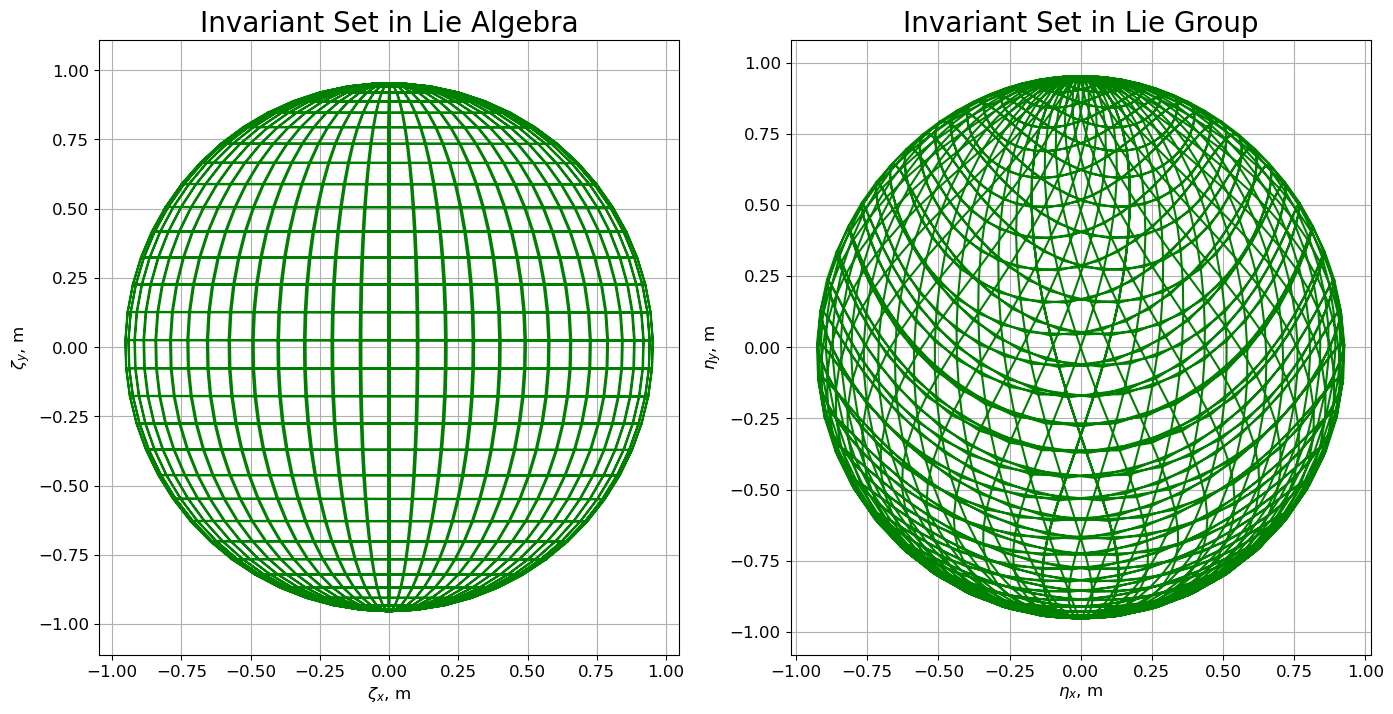

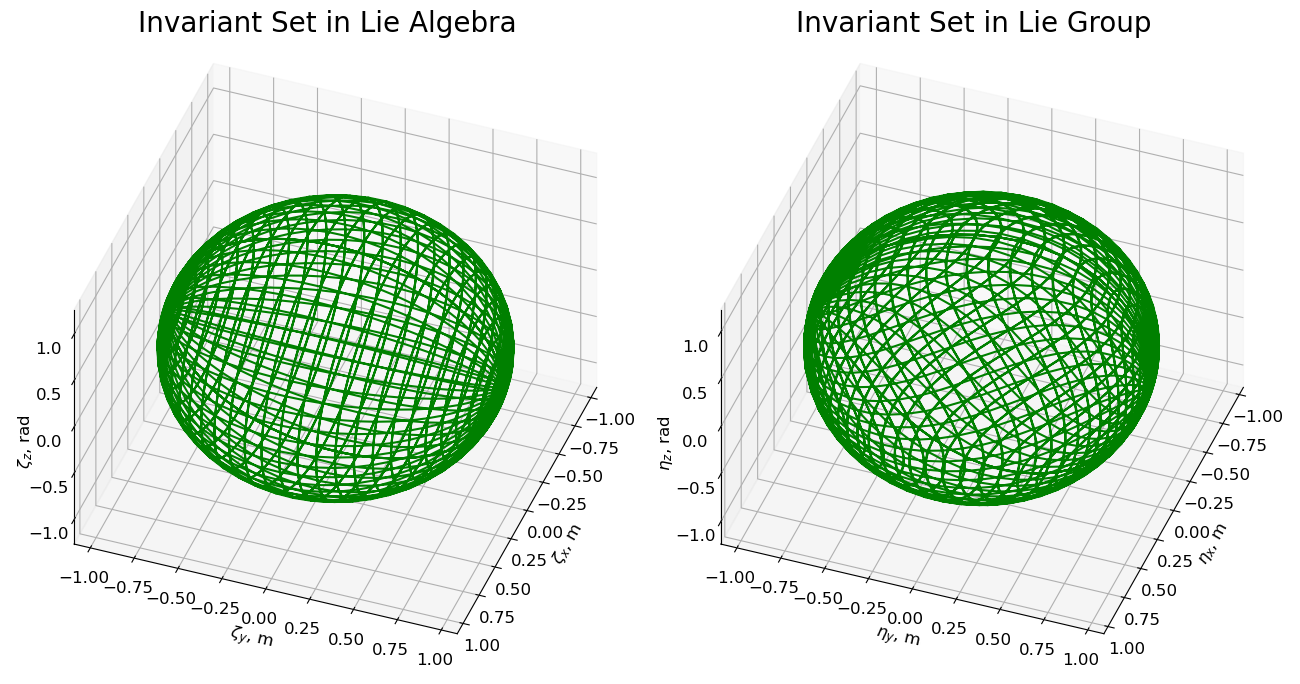

In [17]:
plt.figure(figsize=(14,7))
plt.rcParams.update({'font.size': 12})
ax1 = plt.subplot(121)
ax1.plot(points[0, :], points[1, :], 'g', label='with Dynamic Inversion')
# ax.plot(pointscl[0, :], pointscl[1, :], 'b', linewidth=0.5, label='without Dynamic Inversion')
ax1.set_xlabel('$\\zeta_x$, m')
ax1.set_ylabel('$\\zeta_y$, m')
# ax.plot(xopt.x,xopt.y,'ro')
plt.axis('equal')
plt.grid(True)
# plt.legend(loc=1)
ax2 = plt.subplot(122)
ax2.plot(inv_points[0, :-1], inv_points[1, :-1], 'g', label='with Dynamic Inversion')
# ax2.plot(inv_pointscl[0, :-1], inv_pointscl[1, :-1], 'b', linewidth=0.5, label='without Dynamic Inversion')
# ax2.plot(e[0],e[1],'ro')
ax2.set_xlabel('$\\eta_x$, m')
ax2.set_ylabel('$\\eta_y$, m')
plt.grid(True)
# plt.legend(loc=1)
plt.axis('equal')
plt.tight_layout()
ax1.set_title('Invariant Set in Lie Algebra', fontsize=20)
ax2.set_title('Invariant Set in Lie Group', fontsize=20)
plt.savefig('figures/mr_Invariant_l.eps', format='eps', bbox_inches='tight')

plt.figure(figsize=(14,7))
ax1 = plt.subplot(121, projection='3d', proj_type='ortho', elev=40, azim=20)
# ax.plot3D(e0[0], e0[1], e0[2], 'ro');
ax1.plot3D(points[0, :], points[1, :], points[2, :],'g', label='with Dynamic Inversion')
# ax.plot3D(pointscl[0, :], pointscl[1, :], pointscl[2, :],'b', linewidth=0.5, label='without Dynamic Inversion')
ax1.set_xlabel('$\\zeta_x$, m')
ax1.set_ylabel('$\\zeta_y$, m')
ax1.set_zlabel('$\\zeta_z$, rad', labelpad=1)
ax1.set_title('Invariant Set in Lie Algebra', fontsize=20)
# plt.subplots_adjust(left=9, right=10, top=0.5, bottom=0.08)
# plt.tight_layout()
plt.axis('auto')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
# plt.legend(loc=1)
ax2 = plt.subplot(122, projection='3d', proj_type='ortho', elev=40, azim=20)
# ax2.plot3D(e[0], e[1], e[2], 'ro');
ax2.plot3D(inv_points[0, :], inv_points[1, :], inv_points[2, :], 'g', label='with Dynamic Inversion')
# ax2.plot3D(inv_pointscl[0, :], inv_pointscl[1, :], inv_pointscl[2, :], 'b', linewidth=0.5, label='without Dynamic Inversion')
# ax2.plot3D(e[0], e[1], e[2], 'ro');
ax2.set_xlabel('$\\eta_x$, m')
ax2.set_ylabel('$\\eta_y$, m')
ax2.set_zlabel('$\\eta_z$, rad')
ax2.set_title('Invariant Set in Lie Group', fontsize=20)
plt.axis('auto')
plt.subplots_adjust(left=0.45, right=1, top=0.5, bottom=0.08)
# plt.legend(loc=1)
plt.tight_layout()
plt.savefig('figures/mr_Invariant3d_l.eps', format='eps', bbox_inches='tight')

In [18]:
def iter_dist(w1, w2, sol, t, beta):
    v1 = np.pi
    v3 = np.pi
    for i in np.linspace(0, 100, 101):
        w1_update = v1*w1 + v3*w2
        points, _ = se23_invariant_set_points_theta(sol, t, w1_update, w2, beta)
        theta1 = max(points[0, :].max(), abs(points[0, :].min()))
        theta2 = max(points[1, :].max(), abs(points[1, :].min()))
        theta3 = max(points[2, :].max(), abs(points[2, :].min()))
        points, _ = se23_invariant_set_points_v(sol, t, w1_update, w2, beta)
        a1 = max(points[0, :].max(), abs(points[0, :].min()))
        a2 = max(points[1, :].max(), abs(points[1, :].min()))
        a3 = max(points[2, :].max(), abs(points[2, :].min()))
        # print(a1, a2, a3)
        R = lie.so3.elem(ca.vertcat(theta1, theta2, theta3)).left_jacobian_inv()
        a = lie.se3.elem(ca.vertcat(a1, a2, a3, theta1, theta2, theta3))
        Ql = a.left_Q(a.v_b, a.Omega)
        Q_inv = -R @ Ql @ R
        v2 = np.linalg.svd(ca.DM(R))[1].max()
        # v4 = np.linalg.svd(ca.DM(Q_inv))[1].max()
        # print(v4)
        if abs(v1) > abs(v2):
            if abs(v1 - v2) > .1:
                v1 = v2
            else:
                break
        else:
            v1 = v1
            
    return v1*w1

In [19]:
new_w1 = iter_dist(w1, w2, sol_LMI, 20, ebeta)
new_w1

1.1151430714428394

In [20]:
# Calculate convex hull for flow pipes
n = 10 # number of flow pipes
flowpipes_traj, intervalhull_traj, nom_traj, t_vect = flowpipes(ref, n, ebeta, w1, omegabound, sol_LMI, 'xy')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


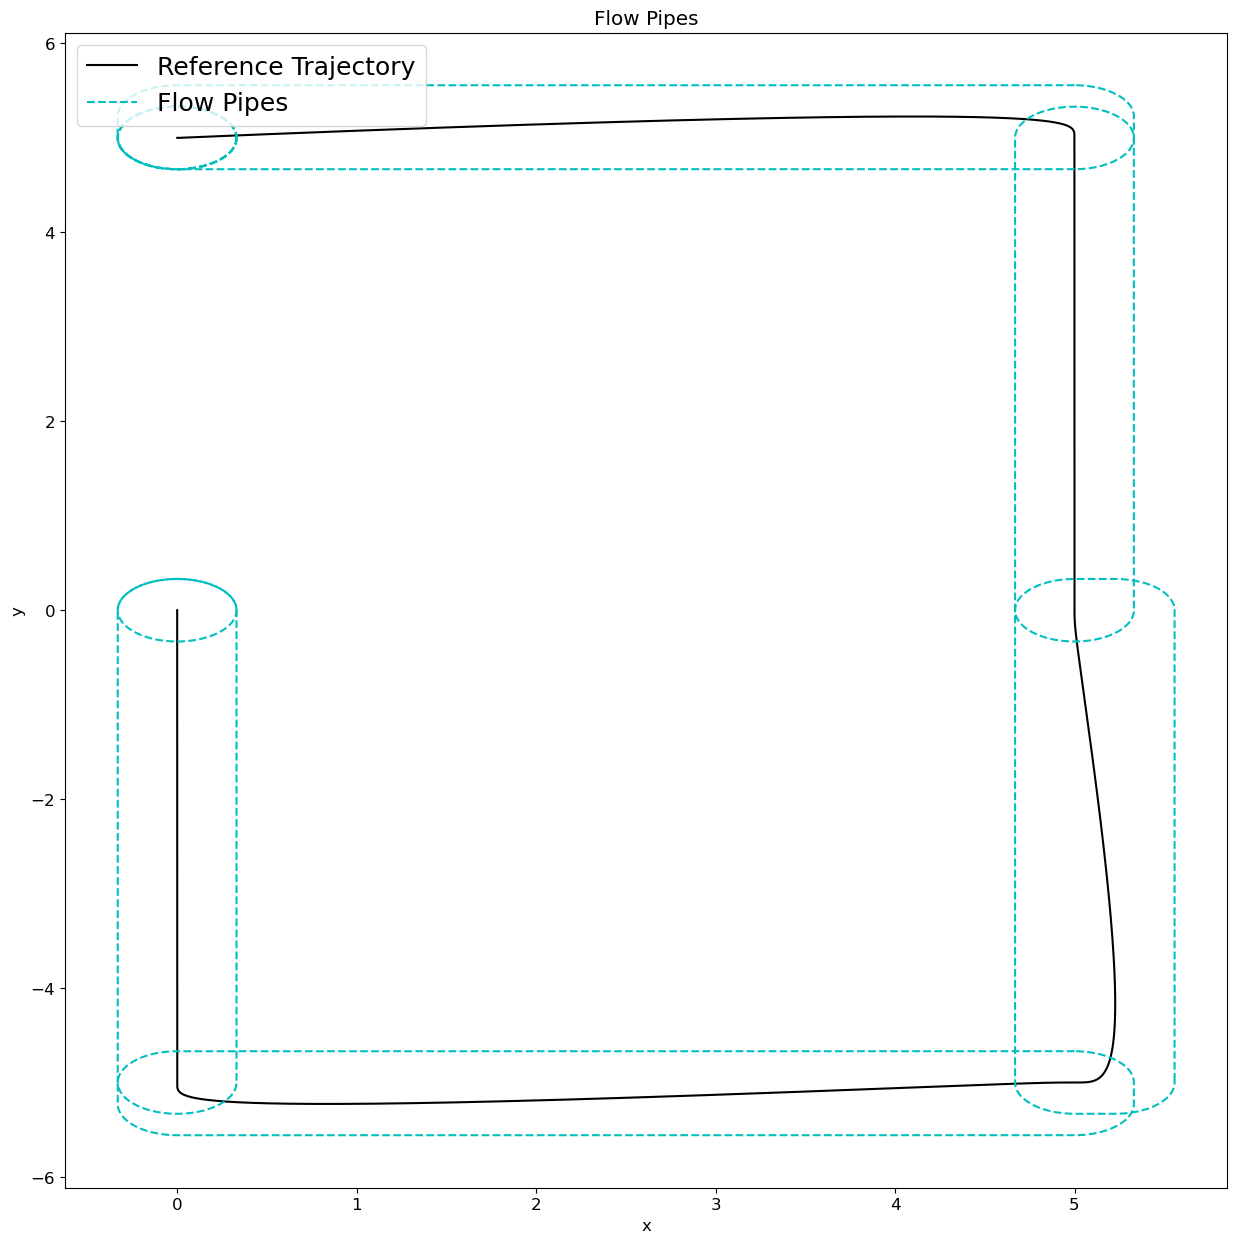

In [20]:
plot_flowpipes(nom_traj, flowpipes_traj, n, 'xy')

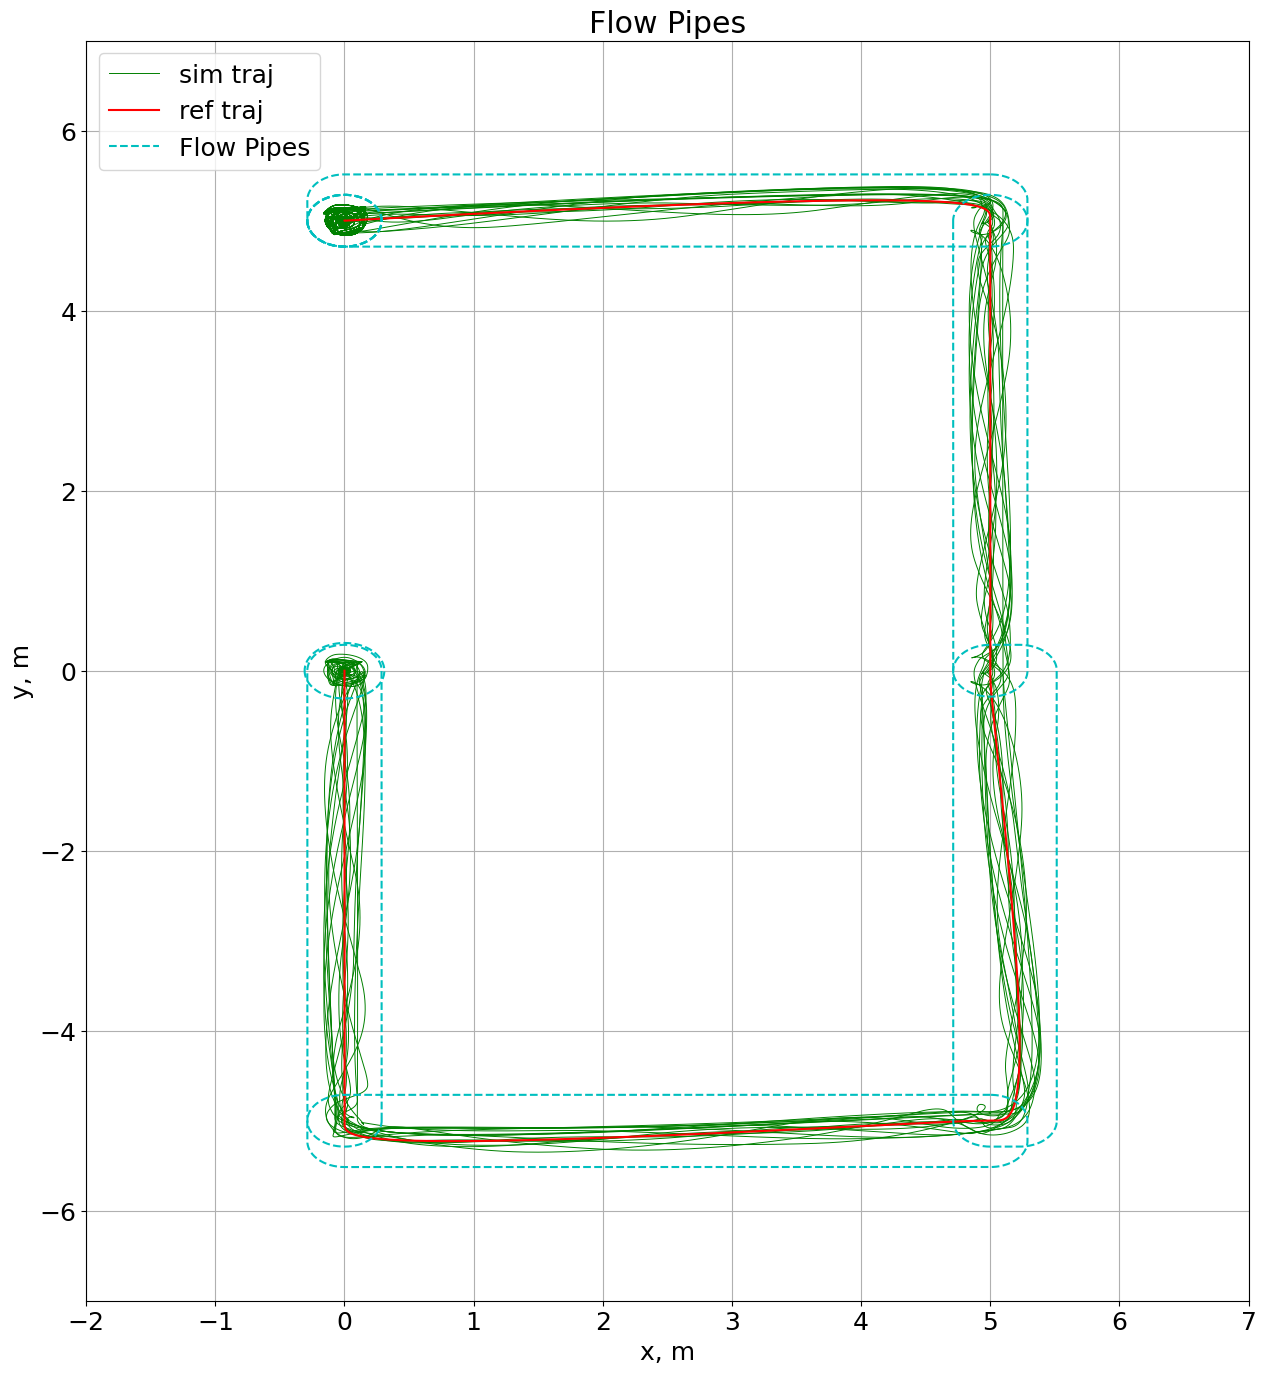

In [27]:
from sim.multirotor_ca_sim import plot_sim
plot_sim(ref, t_list, T0, PX_list, PY_list, PZ_list, Ppsi_list, flowpipes_traj, n, 'xy')

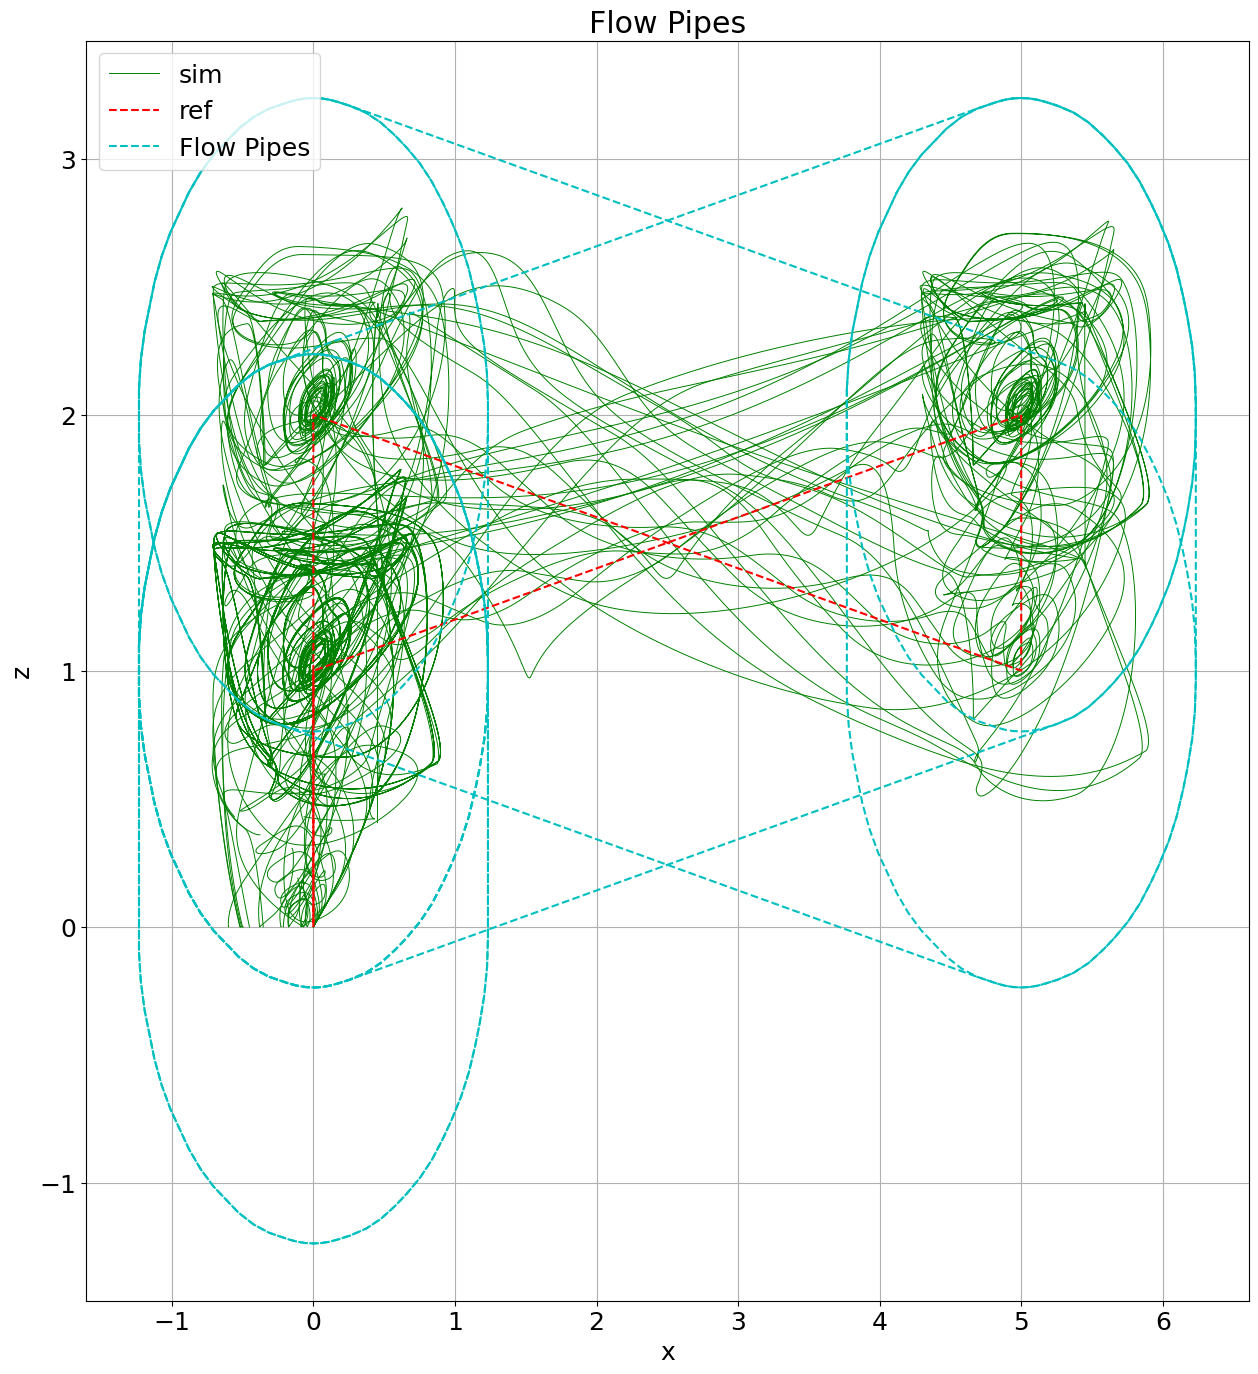

In [27]:
from sim.multirotor_ca_sim import plot_sim
flowpipes_traj, intervalhull_traj, nom_traj, t_vect = flowpipes(ref, n, ebeta, new_w1, omegabound, sol_LMI, 'xz')
plot_sim(ref, t_list, T0, PX_list, PY_list, PZ_list, Ppsi_list, flowpipes_traj, n, 'xz')

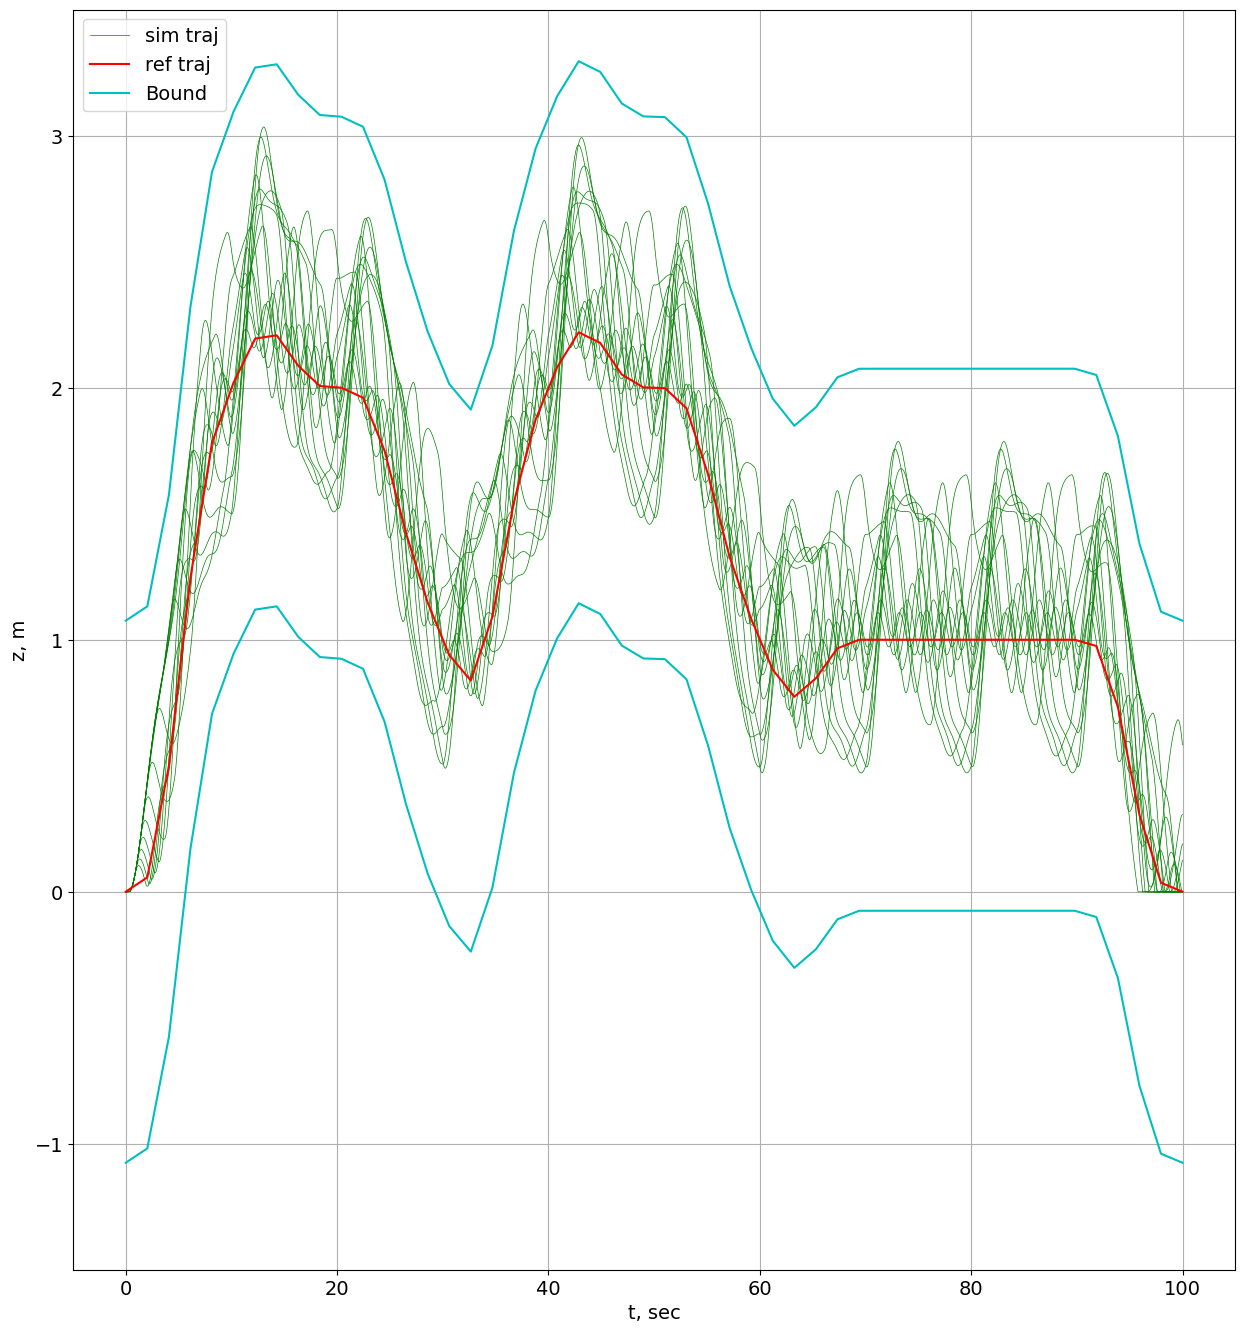

In [21]:
plot_timehis(t_list, T0, dt, PX_list, PY_list, PZ_list, Ppsi_list, sol_LMI, ref, w1, omegabound, 50, ebeta)

In [24]:
len(t_list)

20000

In [28]:
ref['T0']

[40, 40, 40, 40, 40, 40, 40, 40, 40, 40]

In [ ]:
from cyecca.lie import se23
x = ca.SX.sym('x')
y = ca.SX.sym('y')
z = ca.SX.sym('z')
vx = ca.SX.sym('vx')
vy = ca.SX.sym('vy')
vz = ca.SX.sym('vz')
omega1 = ca.SX.sym('omega1')
omega2 = ca.SX.sym('omega2')
omega3 = ca.SX.sym('omega3')

In [159]:
A = se23.elem(ca.vertcat(0,1.5,1,1,2,3,2.5,2,2.5))
np.linalg.svd(ca.DM(A.left_jacobian()[6:,6:]))[1]

array([1.74952691, 1.74952691, 1.        ])

In [164]:
ca.DM(A.left_jacobian())

DM(
[[-0.33318, -0.163216, 1.46375, 00, 00, 00, -0.386808, 0.29971, -0.183491], 
 [1.46388, -0.62583, -0.163216, 00, 00, 00, -0.156571, 0.138179, 0.541973], 
 [0.162077, 1.46388, -0.33318, 00, 00, 00, 0.0453117, -0.108912, -0.0244062], 
 [00, 00, 00, -0.33318, -0.163216, 1.46375, -0.622201, 0.534174, -0.380414], 
 [00, 00, 00, 1.46388, -0.62583, -0.163216, -0.538813, -0.175402, 1.0187], 
 [00, 00, 00, 0.162077, 1.46388, -0.33318, 0.555817, -0.443495, 0.102603], 
 [00, 00, 00, 00, 00, 00, -0.33318, -0.163216, 1.46375], 
 [00, 00, 00, 00, 00, 00, 1.46388, -0.62583, -0.163216], 
 [00, 00, 00, 00, 00, 00, 0.162077, 1.46388, -0.33318]])

In [165]:
ca.DM(A.left_jacobian()[:3,6:])

DM(
[[-0.386808, 0.29971, -0.183491], 
 [-0.156571, 0.138179, 0.541973], 
 [0.0453117, -0.108912, -0.0244062]])

In [138]:
from sympy import *

In [139]:
theta, rho, gamma = symbols('theta, rho, gamma', real=True)
i = I
ad_v = Matrix([[0, -theta, rho],
               [theta, 0, -gamma],
               [-rho, gamma, 0]])

In [140]:
exp_ad = ad_v.exp()
exp_ad

Matrix([
[gamma**2/(gamma**2 + rho**2 + theta**2) - gamma*theta*sqrt(gamma**2 + rho**2 + theta**2)*(-gamma**2*rho**2 - gamma**2*theta**2 - rho**4 - rho**2*theta**2)*re(exp(-sqrt(-gamma**2 - rho**2 - theta**2))/(2*gamma**3*theta - 2*I*gamma**2*rho*sqrt(gamma**2 + rho**2 + theta**2) + 2*gamma*rho**2*theta + 2*gamma*theta**3 - 2*I*rho**3*sqrt(gamma**2 + rho**2 + theta**2) - 2*I*rho*theta**2*sqrt(gamma**2 + rho**2 + theta**2)))/(gamma**2*sqrt(gamma**2 + rho**2 + theta**2) + rho**2*sqrt(gamma**2 + rho**2 + theta**2)) + (-gamma**2*rho - rho**3 - rho*theta**2)*(-gamma**2*rho**2 - gamma**2*theta**2 - rho**4 - rho**2*theta**2)*im(exp(-sqrt(-gamma**2 - rho**2 - theta**2))/(2*gamma**3*theta - 2*I*gamma**2*rho*sqrt(gamma**2 + rho**2 + theta**2) + 2*gamma*rho**2*theta + 2*gamma*theta**3 - 2*I*rho**3*sqrt(gamma**2 + rho**2 + theta**2) - 2*I*rho*theta**2*sqrt(gamma**2 + rho**2 + theta**2)))/(gamma**2*sqrt(gamma**2 + rho**2 + theta**2) + rho**2*sqrt(gamma**2 + rho**2 + theta**2)) - (-gamma**2*rho**2*s

In [142]:
k = symbols('k', real=True, integer=True)
A = summation(((-1)**k/factorial(k+1))*ad_v**k, (k, 0, oo))

A = A.applyfunc(lambda term: term.expand(complex=True).factor().collect([theta, rho, gamma]).simplify())
A

KeyboardInterrupt: 

In [ ]:
A_inv = A.inv().applyfunc(lambda term: term.simplify().factor())@eye(3)  # multiply by identify to make non-immutable
A_inv = A_inv.applyfunc(lambda term: term.collect([x, y]).collect(theta))
A_inv

In [ ]:
U = A_inv@(-ad_v).exp()
U = -U.applyfunc(lambda term: term.trigsimp().collect([x, y]))
U[0, 2] = U[0, 2].collect([x, y])
U[1, 2] = U[1, 2].collect([x, y])
U

In [ ]:
U_inv = U.inv()
U_inv = U_inv.applyfunc(lambda t: trigsimp(t).collect([x, y]))
U_inv[0, 2] = U_inv[0, 2].collect([theta*y, x, y]).collect(1- cos(theta))
U_inv[1, 2] = U_inv[1, 2].collect([theta*x, x, y]).collect(1- cos(theta))
U_inv

In [ ]:
w_svals = U[2, :].singular_values()[0]
w_svals